<a href="https://colab.research.google.com/github/molluIdontknow/ELE_Algorithm/blob/%EA%B9%80%EC%8B%9C%EC%9A%B0/elealgo_mlp_ipynb%EC%9D%98_%EC%82%AC%EB%B3%B8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [11]:
df = pd.read_csv("merged_features_25C.csv")
df = df.drop(columns=df.columns[:3])
df.to_csv("test.csv",index=False)

In [1]:
import math
import numpy as np
import pandas as pd

def generate_custom_dataset(n_samples=1000, random_state=42):
    np.random.seed(random_state)

    x = np.random.randint(0, 1001, size=n_samples)   # [0, 1000]
    y = np.random.randint(0, 1001, size=n_samples)   # [0, 1000]
    z = np.random.randint(0, 1001, size=n_samples)   # [0, 1000]
    w = np.random.randint(0, 11, size=n_samples)     # [0, 10]
    n = np.random.randint(1, 21, size=n_samples)     # [1, 20]

    # Lookup table 사전 계산 (n=1..20)
    lookup = np.array([0.0] + [7.0 * math.factorial(i) / (i ** i) for i in range(1, 21)])
    factorial_term = lookup[n]

    # 타겟 계산
    target = (
        8 * np.sin(x) +
        9 * np.exp(-y) +
        10 * np.cos(z) +
        w +
        factorial_term
    )

    return pd.DataFrame({'x': x, 'y': y, 'z': z, 'w': w, 'n': n, 'target': target})

# === 사용 예시 ===
df = generate_custom_dataset(n_samples=100)
df.to_csv('dataset.csv', index=False)

# 기본 실행 코드

In [12]:
import os
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

# ==========================================
# 1. 데이터셋 클래스
# [강화 A] 파일 경로 대신, 이미 정규화까지 끝난 x, y numpy 배열을 직접 받도록 변경.
#          이렇게 해야 Train 데이터로만 계산한 정규화 통계(mean, std)를
#          Validation 데이터에도 "그대로" 적용할 수 있어 (Data Leakage 방지).
# ==========================================
class BatteryCSVDataset(Dataset):
    def __init__(self, x_array, y_array):
        self.x = torch.tensor(x_array, dtype=torch.float32)
        self.y = torch.tensor(y_array, dtype=torch.float32).unsqueeze(1)

    def __len__(self):
        return len(self.x)

    def __getitem__(self, idx):
        return self.x[idx], self.y[idx]


# ==========================================
# MLP 모델 클래스 (기본 구조: N -> 16 -> 8 -> 1)
# [강화 B] 각 ReLU 뒤에 Dropout 추가.
#          학습 중 일부 뉴런을 무작위로 꺼서, 모델이 특정 뉴런에
#          과도하게 의존하는 것(Overfitting)을 막아줌.
# ==========================================
class SOHPredictorMLP(nn.Module):
    def __init__(self, input_dim, dropout_rate=0.2):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 16),
            nn.ReLU(),
            nn.Dropout(dropout_rate),   # [강화 B] 추가된 줄
            nn.Linear(16, 8),
            nn.ReLU(),
            nn.Dropout(dropout_rate),   # [강화 B] 추가된 줄
            nn.Linear(8, 1)
        )

    def forward(self, x):
        return self.network(x)

# 모델 실행


=== 모델 학습 시작 (입력 특성 개수: 25) ===

최종 Best Validation Loss: 467.2457

=== 📊 Validation 전체 평가 ===
MAE  (평균 절대 오차) : 17.7255
RMSE (평균 제곱근 오차): 21.6159
Max Error (최대 오차)  : 47.1640

=== 🔍 Feature Importance 계산 중 (Permutation Importance) ===


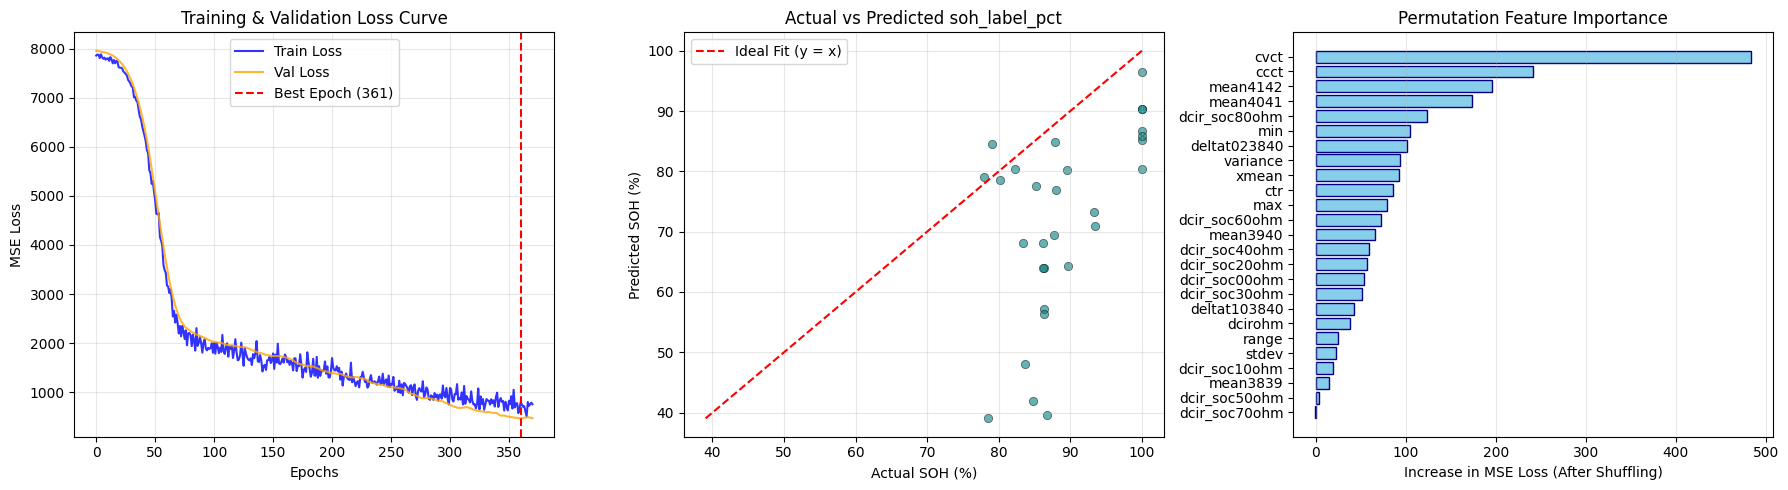

In [16]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# ==========================================
# 0. 하이퍼파라미터 및 실행 설정 (최상단 통합)
# ==========================================
# [데이터 관련 설정]
CSV_FILENAME = "test.csv"
TARGET = "soh_label_pct"
EXCLUDE_COLS = []  # TARGET 외 추가로 제외할 컬럼
DROP_FIRST_N_COLS = 0  # 필요시 앞쪽 N개 열 제거

# [데이터 분할 및 모델 학습 설정]
TEST_SIZE = 0.2
RANDOM_STATE = 42
BATCH_SIZE = 32
LEARNING_RATE = 0.001
WEIGHT_DECAY = 1e-4    # L2 정규화 (Overfitting 방지)
MAX_EPOCHS = 10000
PATIENCE = 10          # Early Stopping 기준
MODEL_SAVE_PATH = "best_model.pt"

# [시각화 설정]
SHOW_PLOTS = True
FIG_SIZE = (18, 5)     # 그래프 3개를 가로로 배치하기 위해 확장

# ==========================================
# 1. 데이터 로드 및 전처리
# ==========================================
df = pd.read_csv(CSV_FILENAME)

# 앞쪽 N개 열 제거가 필요한 경우 적용
if DROP_FIRST_N_COLS > 0:
    df = df.iloc[:, DROP_FIRST_N_COLS:]

# Train / Validation 분리
train_df, val_df = train_test_split(df, test_size=TEST_SIZE, random_state=RANDOM_STATE)

# Feature 이름 추출 및 Target 분리
drop_cols = [TARGET] + EXCLUDE_COLS
feature_names = train_df.drop(columns=drop_cols).columns.tolist() # 특성 이름 저장

X_train_raw = train_df.drop(columns=drop_cols).values
y_train = train_df[TARGET].values

X_val_raw = val_df.drop(columns=drop_cols).values
y_val = val_df[TARGET].values

# Feature 정규화 (Z-Score Normalization)
x_mean = X_train_raw.mean(axis=0)
x_std = X_train_raw.std(axis=0)
x_std[x_std == 0] = 1e-8  # Zero-Division 방지

X_train = (X_train_raw - x_mean) / x_std
X_val = (X_val_raw - x_mean) / x_std

# ==========================================
# 2. Dataset 및 DataLoader 구성
# ==========================================
# Note: BatteryCSVDataset, SOHPredictorMLP는 미리 정의되어 있어야 합니다.
train_dataset = BatteryCSVDataset(X_train, y_train)
val_dataset = BatteryCSVDataset(X_val, y_val)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

# 입력 특성 차원수 자동 설정
input_dim = X_train.shape[1]
model = SOHPredictorMLP(input_dim=input_dim)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

# ==========================================
# 3. 평가 함수
# ==========================================
def evaluate(model, loader, criterion):
    model.eval()
    total_loss = 0.0
    with torch.no_grad():
        for bx, by in loader:
            pred = model(bx)
            total_loss += criterion(pred, by).item()
    model.train()
    return total_loss / len(loader)

# ==========================================
# 4. 모델 학습 및 Early Stopping
# ==========================================
print(f"\n=== 모델 학습 시작 (입력 특성 개수: {input_dim}) ===")

best_val_loss = float('inf')
patience_counter = 0

train_loss_history = []
val_loss_history = []

for epoch in range(1, MAX_EPOCHS + 1):
    model.train()
    total_train_loss = 0.0

    for batch_x, batch_y in train_loader:
        optimizer.zero_grad()
        pred_y = model(batch_x)
        loss = criterion(pred_y, batch_y)
        loss.backward()
        optimizer.step()
        total_train_loss += loss.item()

    train_loss = total_train_loss / len(train_loader)
    val_loss = evaluate(model, val_loader, criterion)

    train_loss_history.append(train_loss)
    val_loss_history.append(val_loss)


    # Early Stopping 판정
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save(model.state_dict(), MODEL_SAVE_PATH)
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            break

# 최고 성능 모델 불러오기
model.load_state_dict(torch.load(MODEL_SAVE_PATH, weights_only=True))
print(f"\n최종 Best Validation Loss: {best_val_loss:.4f}")

# ==========================================
# 5. Validation 전체 평가 (MAE, RMSE, Max Error)
# ==========================================
model.eval()
all_actuals, all_preds = [], []

with torch.no_grad():
    for batch_x, batch_y in val_loader:
        pred = model(batch_x)
        all_actuals.append(batch_y)
        all_preds.append(pred)

all_actuals = torch.cat(all_actuals).numpy().flatten()
all_preds = torch.cat(all_preds).numpy().flatten()
abs_error = np.abs(all_actuals - all_preds)

mae = abs_error.mean()
rmse = np.sqrt(((all_actuals - all_preds) ** 2).mean())
max_error = abs_error.max()

print("\n=== 📊 Validation 전체 평가 ===")
print(f"MAE  (평균 절대 오차) : {mae:.4f}")
print(f"RMSE (평균 제곱근 오차): {rmse:.4f}")
print(f"Max Error (최대 오차)  : {max_error:.4f}")

# ==========================================
# 6. Permutation Feature Importance 계산
# ==========================================
print("\n=== 🔍 Feature Importance 계산 중 (Permutation Importance) ===")
baseline_val_loss = best_val_loss
importance_scores = []

# Validation 데이터 텐서 준비
val_x_tensor = torch.tensor(X_val, dtype=torch.float32)
val_y_tensor = torch.tensor(y_val, dtype=torch.float32)

for col_idx in range(input_dim):
    # 특성 값 셔플 (기존 데이터 복사 후 특정 열만 무작위로 섞음)
    X_val_permuted = val_x_tensor.clone()
    shuffled_indices = torch.randperm(X_val_permuted.size(0))
    X_val_permuted[:, col_idx] = X_val_permuted[shuffled_indices, col_idx]

    # 셔플된 데이터로 Loss 재계산
    with torch.no_grad():
        perm_preds = model(X_val_permuted).squeeze()
        perm_loss = criterion(perm_preds, val_y_tensor).item()

    # Importance = 셔플 후 Loss - 기준 Loss (Loss 상승폭이 클수록 중요한 변수)
    importance = perm_loss - baseline_val_loss
    importance_scores.append(importance)

# 중요도 순으로 정렬된 DataFrame 생성
fi_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importance_scores
}).sort_values(by='Importance', ascending=True)


# ==========================================
# 7. 시각화 (Loss 곡선 & 실제/예측 & Feature Importance)
# ==========================================
if SHOW_PLOTS:
    fig, axes = plt.subplots(1, 3, figsize=FIG_SIZE)

    # 1) Train vs Validation Loss 곡선
    axes[0].plot(train_loss_history, label='Train Loss', color='blue', alpha=0.8)
    axes[0].plot(val_loss_history, label='Val Loss', color='orange', alpha=0.8)
    axes[0].axvline(x=np.argmin(val_loss_history), color='red', linestyle='--', label=f'Best Epoch ({np.argmin(val_loss_history)+1})')
    axes[0].set_title("Training & Validation Loss Curve", fontsize=12)
    axes[0].set_xlabel("Epochs")
    axes[0].set_ylabel("MSE Loss")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # 2) 실제값 vs 예측값 산점도 (Scatter Plot)
    axes[1].scatter(all_actuals, all_preds, alpha=0.6, color='teal', edgecolors='k', linewidths=0.5)
    min_val = min(all_actuals.min(), all_preds.min())
    max_val = max(all_actuals.max(), all_preds.max())
    axes[1].plot([min_val, max_val], [min_val, max_val], 'r--', label='Ideal Fit (y = x)')
    axes[1].set_title(f"Actual vs Predicted {TARGET}", fontsize=12)
    axes[1].set_xlabel("Actual SOH (%)")
    axes[1].set_ylabel("Predicted SOH (%)")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    # 3) Feature Importance 막대 그래프 (Horizontal Bar Plot)
    axes[2].barh(fi_df['Feature'], fi_df['Importance'], color='skyblue', edgecolor='navy')
    axes[2].set_title("Permutation Feature Importance", fontsize=12)
    axes[2].set_xlabel("Increase in MSE Loss (After Shuffling)")
    axes[2].grid(True, alpha=0.3, axis='x')

    plt.tight_layout()
    plt.show()